# **Quantum Chemistry: Ground State and Excited Energy Solver**

In [ ]:
!pip install qiskit
!pip install qiskit-nature
!pip install qiskit-ibm-runtime
!pip install qiskit-aer
!pip install qiskit-algorithms

In [ ]:
!pip install qiskit['visualization']

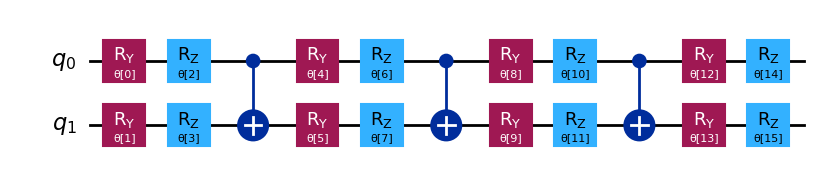

In [3]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import EfficientSU2

H2_op = SparsePauliOp.from_list(
    [
        ("II", -1.052373245772859),
        ("IZ", 0.39793742484318045),
        ("ZI", -0.39793742484318045),
        ("ZZ", -0.01128010425623538),
        ("XX", 0.18093119978423156),
    ]
)

chem_ansatz = EfficientSU2(H2_op.num_qubits)

chem_ansatz.decompose().draw("mpl")

In [4]:
from qiskit.circuit.library import TwoLocal
from qiskit import QuantumCircuit


def cost_func_vqe(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (Estimator): Estimator primitive instance

    Returns:
        float: Energy estimate
    """
    pub = (ansatz, hamiltonian, params)
    cost = estimator.run([pub]).result()[0].data.evs
#    cost = estimator.run(ansatz, hamiltonian, parameter_values=params).result().values[0]
    return cost

In [5]:
#set an initial set of parameters
import numpy as np

x0 = np.ones(chem_ansatz.num_parameters)

We can minimize this cost function to calculate optimal parameters, and we can check our code first by using a local simulator

In [6]:
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.primitives import StatevectorSampler as Sampler
estimator = Estimator()
sampler = Sampler()

In [7]:
# SciPy minimizer routine
from scipy.optimize import minimize
import time

start_time = time.time()

result = minimize(cost_func_vqe, x0, args=(chem_ansatz, H2_op, estimator), method="COBYLA")

end_time = time.time()
execution_time = end_time - start_time

result

 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -1.857275029958007
       x: [ 8.729e-01  1.581e+00 ...  8.733e-01  1.116e+00]
    nfev: 260
   maxcv: 0.0

In [ ]:
#Try on real quantum hardware
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import Session, EstimatorOptions
from qiskit_ibm_runtime import QiskitRuntimeService


service = QiskitRuntimeService(channel='ibm_quantum')
backend = service.least_busy(operational=True, simulator=False)

In [ ]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_ansatz = pm.run(ansatz)
isa_observable = H2_op.apply_layout(layout = isa_ansatz.layout)

In [ ]:
x0=[ 1.306e+00, -2.284e-01,  6.913e-02, -2.530e-02,  1.849e+00,
            7.433e-02,  6.366e-01,  5.600e-01]

In [ ]:
#Estimated hardware usage: 20 min benchmarked on ibm_nazca on 5-30-24

real_prev_states = []
real_prev_opt_parameters = []
real_eigenvalues = []

realbackend = 1

estimator_options = EstimatorOptions(
    resilience_level=1,
    default_shots = 4096
)

with Session(backend=backend) as session:

    estimator = Estimator(mode=session)
    sampler = Sampler(mode = session)

    for step in range(1, k + 1):

        if step > 1:
            real_prev_states.append(isa_ansatz.assign_parameters(real_prev_opt_parameters))

        result = minimize(cost_func_vqd, x0, args=(isa_ansatz, real_prev_states, step, betas, estimator, sampler, isa_observable, realbackend, backend), method="COBYLA", options = {'tol': 0.001, 'maxiter':300})
        print(result)

        real_prev_opt_parameters = result.x
        real_eigenvalues.append(result.fun)

session.close()
print(real_eigenvalues)